# File 6 — Forecasting & Early Warning System

**Project:** Irish Crime Intelligence Platform

---

## What this file does

Takes 22 years of historical crime data and builds forecasts at three levels — national, cluster, and individual station. The idea is to give planners a forward-looking view so they can see where workload is likely to rise before it actually happens.

## Objectives
1. Forecast national crime trend for 2025 and 2026
2. Forecast each of the 4 strategy clusters separately
3. Forecast the top 50 highest-risk stations
4. Evaluate model accuracy against a simple naive baseline
5. Flag stations showing significant predicted growth

## Data we're using
| File | What we need |
|---|---|
| `ireland_crime_structured_dataset.csv` | 22 years of incident counts |
| `Garda_Station_Strategy_Master.csv` | cluster label for each station |
| `station_risk_metrics_full.csv` | risk rank so we can pick the top 50 |

## What we produce
| File | What it contains |
|---|---|
| `national_forecasts.csv` | national 2025-2026 forecast with confidence interval |
| `cluster_forecasts.csv` | same but for each of the 4 clusters |
| `station_forecasts.csv` | top 50 station forecasts for 2025-2026 |
| `early_warning_stations.csv` | growth and pressure alert flags per station |

---
## Section 1 — Setup and Load Data

In [25]:
# prophet doesnt come with colab so need to install it
# pmdarima is for auto arima later
!pip install prophet --quiet
!pip install pmdarima --quiet

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# forecasting libraries
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima

# for measuring how good the forecasts are
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

pd.set_option('display.max_columns', 50)
print('libraries loaded')

libraries loaded


In [27]:
# load the 3 files we need
df     = pd.read_csv('ireland_crime_structured_dataset.csv')
master = pd.read_csv('Garda_Station_Strategy_Master.csv')
risk   = pd.read_csv('station_risk_metrics_full.csv')

print('crime data:', df.shape)
print('station master:', master.shape)
print('risk file:', risk.shape)

crime data: (173712, 7)
station master: (564, 11)
risk file: (564, 16)


In [28]:
# we need 3 different tables for the 3 forecast levels

# national total by year
national_ts = df.groupby('year')['incidents'].sum().reset_index()
national_ts = national_ts.sort_values('year').reset_index(drop=True)

# add cluster labels before making cluster totals
master_cluster = master[['station_code', 'strategy_cluster']].drop_duplicates('station_code')
df_with_cluster = df.merge(master_cluster, on='station_code', how='left')
missing_cluster_codes = sorted(
    df_with_cluster.loc[df_with_cluster['strategy_cluster'].isna(), 'station_code']
    .dropna()
    .unique()
    .tolist()
)
cluster_ts = (
    df_with_cluster.dropna(subset=['strategy_cluster'])
    .groupby(['strategy_cluster', 'year'])['incidents']
    .sum()
    .reset_index()
)

# only top 50 stations for station forecasts
top50_codes = risk[risk['rank_risk'] <= 50]['station_code'].tolist()
station_ts = (
    df[df['station_code'].isin(top50_codes)]
    .groupby(['station_code', 'station_name', 'year'])['incidents']
    .sum()
    .reset_index()
)

print('national rows:', len(national_ts), '(one per year)')
print('cluster rows:', len(cluster_ts))
print('station rows:', len(station_ts), '- covers', station_ts['station_code'].nunique(), 'stations')

if missing_cluster_codes:
    print('warning:', len(missing_cluster_codes), 'station codes had no cluster label so they were left out of cluster forecasts')
else:
    print('cluster merge check: all station codes matched a cluster')


national rows: 22 (one per year)
cluster rows: 88
station rows: 1100 - covers 50 stations


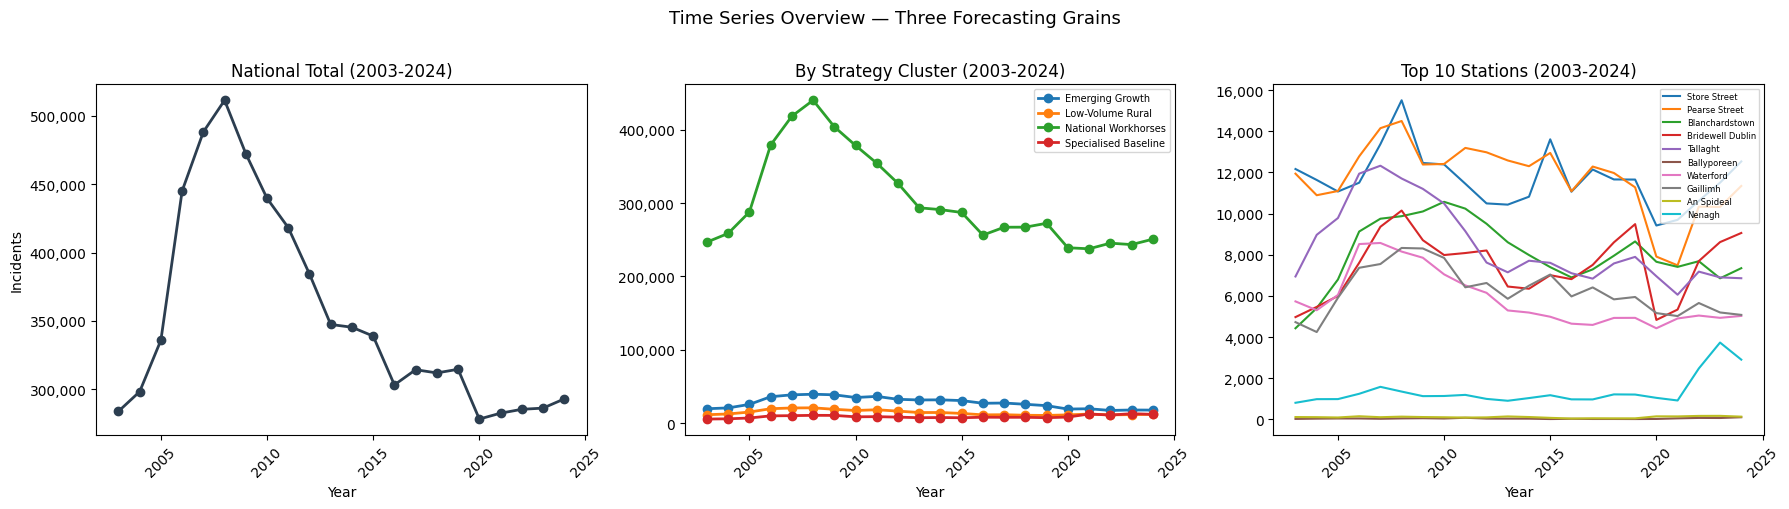

In [29]:
# quick look at all 3 before we do anything else

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# national trend
axes[0].plot(national_ts['year'], national_ts['incidents'], marker='o', linewidth=2, color='#2C3E50')
axes[0].set_title('National Total (2003-2024)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Incidents')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

# one line per cluster
for c in cluster_ts['strategy_cluster'].unique():
    sub = cluster_ts[cluster_ts['strategy_cluster'] == c]
    axes[1].plot(sub['year'], sub['incidents'], marker='o', label=c, linewidth=2)
axes[1].set_title('By Strategy Cluster (2003-2024)')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=7)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=45)

# top 10 stations only so the chart isnt too cluttered
top10 = risk[risk['rank_risk'] <= 10]['station_code'].tolist()
for sc in top10:
    sub = station_ts[station_ts['station_code'] == sc]
    if len(sub) > 0:
        axes[2].plot(sub['year'], sub['incidents'], linewidth=1.5, label=sub['station_name'].iloc[0])
axes[2].set_title('Top 10 Stations (2003-2024)')
axes[2].set_xlabel('Year')
axes[2].legend(fontsize=6)
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Time Series Overview — Three Forecasting Grains', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 2 — Series Checks Before Modelling

Before picking a model I want to check two things:
1. Is the national series stationary or does it have a trend?
2. How bad was the 2020 COVID disruption as a structural break?

These checks are what led me to choose Prophet over plain ARIMA at national and cluster level.

In [30]:
# ADF test on the national series
# this checks whether the series has a unit root - basically whether it has a trend or not
# null hypothesis is that the series has a unit root (non-stationary)
# if p < 0.05 we reject that and say its stationary
# if p >= 0.05 we fail to reject - trend is present

adf_result = adfuller(national_ts['incidents'])

print('ADF Test — National Incident Series')
print(f'Statistic : {adf_result[0]:.4f}')
print(f'p-value   : {adf_result[1]:.4f}')
print()

if adf_result[1] >= 0.05:
    print('Non-stationary (p >= 0.05) — there is a trend in the series')
    print('Prophet handles this natively so we dont need to difference the series manually')
else:
    print('ADF says stationary (p < 0.05)')
    print('But visually there is clearly a structural peak-decline pattern in this data')
    print('The ADF result here is likely influenced by the reversal pattern')
    print('Prophet is still the right choice because of the changepoints')

ADF Test — National Incident Series
Statistic : -1.6381
p-value   : 0.4633

Non-stationary (p >= 0.05) — there is a trend in the series
Prophet handles this natively so we dont need to difference the series manually


In [31]:
# check the 2020 COVID dip - how big was it and did the series recover

y_2019 = national_ts[national_ts['year'] == 2019]['incidents'].values[0]
y_2020 = national_ts[national_ts['year'] == 2020]['incidents'].values[0]
y_2021 = national_ts[national_ts['year'] == 2021]['incidents'].values[0]

drop     = (y_2019 - y_2020) / y_2019 * 100
recovery = (y_2021 - y_2020) / y_2020 * 100

print(f'2019 incidents : {y_2019:,}')
print(f'2020 incidents : {y_2020:,}  ({drop:.1f}% drop from 2019)')
print(f'2021 incidents : {y_2021:,}  ({recovery:.1f}% recovery from 2020)')
print()
print('2020 is a known structural break from COVID-19 lockdowns, not a real crime trend shift')
print('I will pass 2020-01-01 as an explicit changepoint to Prophet')
print('so the model treats this year as a disruption and not a new trend direction')

2019 incidents : 314,681
2020 incidents : 278,277  (11.6% drop from 2019)
2021 incidents : 282,568  (1.5% recovery from 2020)

2020 is a known structural break from COVID-19 lockdowns, not a real crime trend shift
I will pass 2020-01-01 as an explicit changepoint to Prophet
so the model treats this year as a disruption and not a new trend direction


**Why Prophet and not ARIMA at national/cluster level:**

The ADF test is a supporting diagnostic — the main reasons Prophet is better here are:
- The series has a non-stationary structural trend (peak 2008, decline to 2016, flat from 2017, COVID shock 2020)
- There is a clear structural break in 2020 — Prophet handles changepoints natively
- We only have 22 annual data points — ARIMA is less reliable on short series
- Prophet lets us pass 2020 as an explicit changepoint so it doesnt distort the trend fit

ARIMA is used at station level where we have individual station series and trend modelling matters less than fitting each station's own pattern.

---
## Section 3 — National Forecast (Prophet)

**Steps:**
1. Split into train (2003–2020) and test (2021–2024)
2. First check a naive baseline — just predict next year = this year's value
3. Then fit Prophet and compare against that baseline
4. If Prophet beats it, great — if not, document that honestly
5. Retrain on full data (2003–2024) and forecast 2025–2026

In [32]:
# prophet needs columns named 'ds' for date and 'y' for value
# we have annual data so using 1st of January each year as the date

national_prophet = national_ts.copy()
national_prophet['ds'] = pd.to_datetime(national_prophet['year'].astype(str) + '-01-01')
national_prophet['y']  = national_prophet['incidents']

# split
train_nat = national_prophet[national_prophet['year'] <= 2020]
test_nat  = national_prophet[national_prophet['year'] >= 2021]

print('training on:', len(train_nat), 'years (2003-2020)')
print('testing on :', len(test_nat),  'years (2021-2024)')

training on: 18 years (2003-2020)
testing on : 4 years (2021-2024)


In [33]:
# naive baseline first - just predict next year = this year's value
# this is the simplest thing anyone could do
# if our model cant beat this, its not actually adding any value

baseline_rows = []
for yr in [2021, 2022, 2023, 2024]:
    prev_val   = national_ts[national_ts['year'] == yr - 1]['incidents'].values[0]
    actual_val = national_ts[national_ts['year'] == yr]['incidents'].values[0]
    baseline_rows.append({
        'year': yr,
        'actual': actual_val,
        'baseline_pred': prev_val,
        'error': abs(actual_val - prev_val)
    })

baseline_df   = pd.DataFrame(baseline_rows)
baseline_mae  = mean_absolute_error(baseline_df['actual'], baseline_df['baseline_pred'])
baseline_mape = mean_absolute_percentage_error(baseline_df['actual'], baseline_df['baseline_pred']) * 100

print('Naive Baseline — holdout 2021-2024')
print(f'MAE  : {baseline_mae:,.0f}')
print(f'MAPE : {baseline_mape:.1f}%')
print()
print(baseline_df.to_string(index=False))

Naive Baseline — holdout 2021-2024
MAE  : 3,680
MAPE : 1.3%

 year  actual  baseline_pred  error
 2021  282568         278277   4291
 2022  285394         282568   2826
 2023  286276         285394    882
 2024  292995         286276   6719


In [34]:
# now fit Prophet on training data
# changepoint_prior_scale=0.3 means the model is allowed to be moderately flexible
# higher values = more flexible trend, lower = more rigid

model_nat = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    changepoints=['2020-01-01']
)

model_nat.fit(train_nat[['ds', 'y']])
print('model fitted on training data')

model fitted on training data


In [35]:
# predict on the test period (2021-2024) to see how good the model is

future_test = model_nat.make_future_dataframe(periods=4, freq='YS')
fc_test     = model_nat.predict(future_test)

# pull out just the test years
test_preds = fc_test[fc_test['ds'].dt.year >= 2021][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
test_preds['year'] = test_preds['ds'].dt.year
test_preds = test_preds.merge(test_nat[['year', 'y']], on='year')

prophet_mae  = mean_absolute_error(test_preds['y'], test_preds['yhat'])
prophet_mape = mean_absolute_percentage_error(test_preds['y'], test_preds['yhat']) * 100

print('Prophet — holdout 2021-2024')
print(f'MAE  : {prophet_mae:,.0f}')
print(f'MAPE : {prophet_mape:.1f}%')
print()
print('--- Comparison with Naive Baseline ---')
print(f'{"Model":<20} {"MAE":>10} {"MAPE":>8}')
print(f'{"Naive Baseline":<20} {baseline_mae:>10,.0f} {baseline_mape:>7.1f}%')
print(f'{"Prophet":<20} {prophet_mae:>10,.0f} {prophet_mape:>7.1f}%')
print()
if prophet_mae < baseline_mae:
    print('Prophet beats the naive baseline')
else:
    print('Naive baseline is competitive here - expected because the series is very flat post-2020')
    print('Prophet still adds value for the longer-range forecast because it models the trend')

Prophet — holdout 2021-2024
MAE  : 20,210
MAPE : 7.1%

--- Comparison with Naive Baseline ---
Model                       MAE     MAPE
Naive Baseline            3,680     1.3%
Prophet                  20,210     7.1%

Naive baseline is competitive here - expected because the series is very flat post-2020
Prophet still adds value for the longer-range forecast because it models the trend


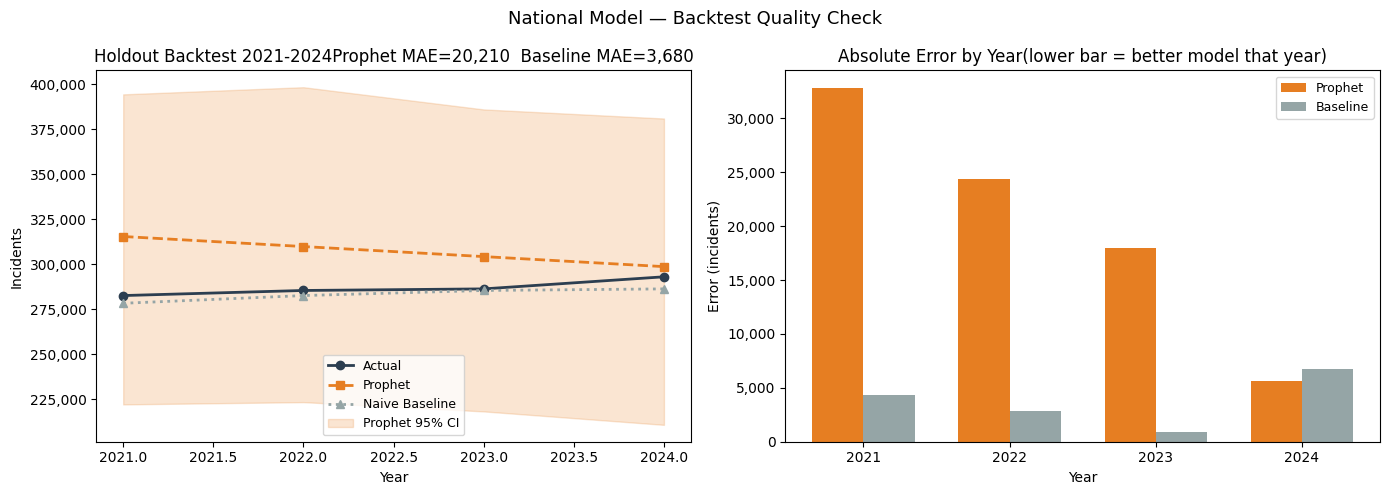

In [36]:
# backtest plot - left panel is actual vs predicted, right panel is error by year
# this shows we are not just forecasting blindly

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: actual vs prophet vs baseline
axes[0].plot(test_preds['year'], test_preds['y'],
             marker='o', linewidth=2, label='Actual', color='#2C3E50')
axes[0].plot(test_preds['year'], test_preds['yhat'],
             marker='s', linewidth=2, linestyle='--', label='Prophet', color='#E67E22')
axes[0].plot(baseline_df['year'], baseline_df['baseline_pred'],
             marker='^', linewidth=2, linestyle=':', label='Naive Baseline', color='#95A5A6')
axes[0].fill_between(test_preds['year'],
                     test_preds['yhat_lower'], test_preds['yhat_upper'],
                     alpha=0.2, color='#E67E22', label='Prophet 95% CI')
axes[0].set_title(f'Holdout Backtest 2021-2024Prophet MAE={prophet_mae:,.0f}  Baseline MAE={baseline_mae:,.0f}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Incidents')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(fontsize=9)
axes[0].grid(False)

# right: absolute error per year for each model
test_preds['prophet_err']  = abs(test_preds['y'] - test_preds['yhat'])
baseline_df['base_err']    = abs(baseline_df['actual'] - baseline_df['baseline_pred'])

x = np.arange(len(test_preds))
w = 0.35
axes[1].bar(x - w/2, test_preds['prophet_err'],  width=w, label='Prophet',   color='#E67E22')
axes[1].bar(x + w/2, baseline_df['base_err'],    width=w, label='Baseline',  color='#95A5A6')
axes[1].set_xticks(x)
axes[1].set_xticklabels(test_preds['year'].values)
axes[1].set_title('Absolute Error by Year(lower bar = better model that year)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Error (incidents)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(fontsize=9)
axes[1].grid(False)

plt.suptitle('National Model — Backtest Quality Check', fontsize=13)
plt.tight_layout()
plt.show()

In [37]:
# retrain on the full dataset (2003-2024) and forecast 2025-2026
# now that we have validated the model we use all the data we have

model_nat_full = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    changepoints=['2020-01-01']
)

model_nat_full.fit(national_prophet[['ds', 'y']])

# make future dataframe - 2 periods ahead = 2025 and 2026
future_full = model_nat_full.make_future_dataframe(periods=2, freq='YS')
fc_nat_full = model_nat_full.predict(future_full)

# pull out 2025-2026 only
nat_out = fc_nat_full[fc_nat_full['ds'].dt.year >= 2025][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
nat_out['year'] = nat_out['ds'].dt.year
nat_out = nat_out.rename(columns={
    'yhat':       'forecast_incidents',
    'yhat_lower': 'lower_ci',
    'yhat_upper': 'upper_ci'
})

print('National forecast:')
print(nat_out[['year', 'forecast_incidents', 'lower_ci', 'upper_ci']].round(0).to_string(index=False))

National forecast:
 year  forecast_incidents  lower_ci  upper_ci
 2025            280505.0  207812.0  362709.0
 2026            274154.0  198105.0  351835.0


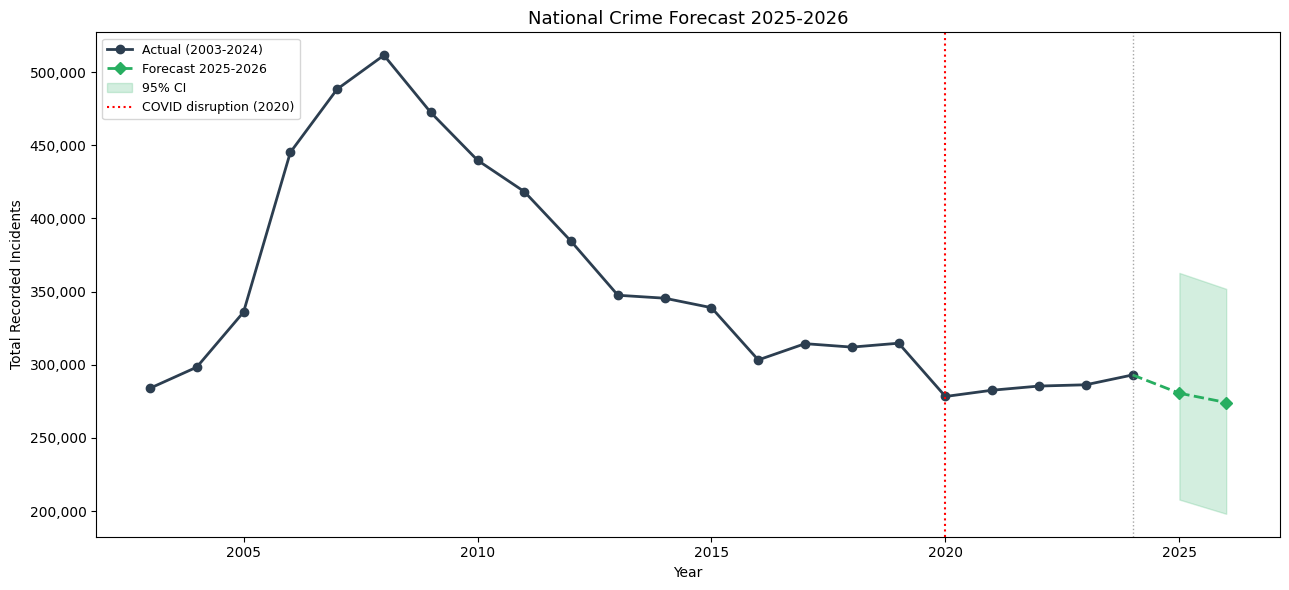

In [38]:
# final forecast plot - full history + forecast with CI

fig, ax = plt.subplots(figsize=(13, 6))

# plot all actual data
ax.plot(national_ts['year'], national_ts['incidents'],
        marker='o', linewidth=2, label='Actual (2003-2024)', color='#2C3E50')

# connect the last actual point to first forecast point
last_actual = national_ts[national_ts['year'] == 2024]['incidents'].values[0]
ax.plot([2024, nat_out['year'].values[0]],
        [last_actual, nat_out['forecast_incidents'].values[0]],
        linewidth=2, linestyle='--', color='#27AE60')

# forecast line
ax.plot(nat_out['year'], nat_out['forecast_incidents'],
        marker='D', linewidth=2, linestyle='--', label='Forecast 2025-2026', color='#27AE60')
ax.fill_between(nat_out['year'], nat_out['lower_ci'], nat_out['upper_ci'],
                alpha=0.2, color='#27AE60', label='95% CI')

ax.axvline(x=2020, color='red', linestyle=':', linewidth=1.5, label='COVID disruption (2020)')
ax.axvline(x=2024, color='grey', linestyle=':', linewidth=1, alpha=0.7)

ax.set_title('National Crime Forecast 2025-2026', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Total Recorded Incidents')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(False)
plt.tight_layout()
plt.show()

---
## Section 4 — Cluster Level Forecasts (Prophet)

Each cluster gets its own Prophet model. The reason I'm not just splitting the national forecast down by cluster is that each cluster has a genuinely different trajectory — National Workhorses follow a different pattern to Emerging Growth. Fitting separately gives more accurate results.

Same train/test split as national: train 2003–2020, evaluate 2021–2024, then retrain on full data for 2025–2026.

In [39]:
cluster_forecasts_list = []
cluster_eval_rows = []
cluster_eval = {}
all_years = set(range(2003, 2025))
clusters = sorted(cluster_ts['strategy_cluster'].dropna().unique())

for cluster in clusters:

    sub = cluster_ts[cluster_ts['strategy_cluster'] == cluster].copy()
    sub = sub.sort_values('year').reset_index(drop=True)
    sub['ds'] = pd.to_datetime(sub['year'].astype(str) + '-01-01')
    sub['y'] = sub['incidents']

    missing_years = sorted(all_years - set(sub['year']))
    if missing_years:
        raise ValueError(f'{cluster} is missing years: {missing_years}')

    train_c = sub[sub['year'] <= 2020].copy()
    test_c = sub[sub['year'] >= 2021].copy()

    baseline_rows = []
    for yr in test_c['year']:
        prev_val = sub[sub['year'] == yr - 1]['incidents'].values[0]
        actual_val = sub[sub['year'] == yr]['incidents'].values[0]
        baseline_rows.append({
            'year': yr,
            'actual': actual_val,
            'baseline_pred': prev_val
        })
    baseline_c = pd.DataFrame(baseline_rows)
    baseline_mae_c = mean_absolute_error(baseline_c['actual'], baseline_c['baseline_pred'])
    baseline_mape_c = mean_absolute_percentage_error(baseline_c['actual'], baseline_c['baseline_pred']) * 100

    m_eval = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        changepoints=['2020-01-01']
    )
    m_eval.fit(train_c[['ds', 'y']])

    future_eval = m_eval.make_future_dataframe(periods=4, freq='YS')
    fc_eval = m_eval.predict(future_eval)
    preds_c = fc_eval[fc_eval['ds'].dt.year >= 2021][['ds', 'yhat']].copy()
    preds_c['year'] = preds_c['ds'].dt.year
    preds_c = preds_c.merge(test_c[['year', 'y']], on='year')

    mae_c = mean_absolute_error(preds_c['y'], preds_c['yhat'])
    mape_c = mean_absolute_percentage_error(preds_c['y'], preds_c['yhat']) * 100

    cluster_eval[cluster] = {
        'mae': mae_c,
        'mape': mape_c,
        'baseline_mae': baseline_mae_c,
        'baseline_mape': baseline_mape_c,
        'beats_baseline': mae_c < baseline_mae_c
    }
    cluster_eval_rows.append({
        'strategy_cluster': cluster,
        'prophet_mae': round(mae_c, 1),
        'baseline_mae': round(baseline_mae_c, 1),
        'prophet_mape': round(mape_c, 2),
        'baseline_mape': round(baseline_mape_c, 2),
        'beats_baseline': mae_c < baseline_mae_c
    })

    m_full = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3,
        changepoints=['2020-01-01']
    )
    m_full.fit(sub[['ds', 'y']])

    future_full = m_full.make_future_dataframe(periods=2, freq='YS')
    fc_full = m_full.predict(future_full)
    future_rows = fc_full[fc_full['ds'].dt.year >= 2025].copy()

    for _, r in future_rows.iterrows():
        cluster_forecasts_list.append({
            'strategy_cluster': cluster,
            'year': r['ds'].year,
            'forecast_incidents': round(r['yhat'], 0),
            'lower_ci': round(r['yhat_lower'], 0),
            'upper_ci': round(r['yhat_upper'], 0)
        })

    if mae_c < baseline_mae_c:
        result_text = 'Prophet beats naive baseline'
    else:
        result_text = 'naive baseline is stronger'

    print(f'{cluster:<25} Prophet MAE={mae_c:,.0f}  Baseline MAE={baseline_mae_c:,.0f}  -> {result_text}')

cluster_forecasts_df = pd.DataFrame(cluster_forecasts_list)
cluster_eval_df = pd.DataFrame(cluster_eval_rows)

print()
print('cluster forecasts done')
display(cluster_forecasts_df)
print()
print('cluster holdout diagnostics (2021-2024)')
display(cluster_eval_df)


Emerging Growth            MAE=8,813  MAPE=48.5%
Low-Volume Rural           MAE=873  MAPE=7.2%
National Workhorses        MAE=16,171  MAPE=6.7%
Specialised Baseline       MAE=3,902  MAPE=31.7%

cluster forecasts done


,strategy_cluster,year,forecast_incidents,lower_ci,upper_ci
0,Emerging Growth,2025,20703.0,12244.0,28269.0
1,Emerging Growth,2026,20072.0,12174.0,28270.0
2,Low-Volume Rural,2025,10761.0,7089.0,14314.0
3,Low-Volume Rural,2026,10438.0,7068.0,13800.0
4,National Workhorses,2025,238219.0,172216.0,300629.0
5,National Workhorses,2026,232667.0,169061.0,302771.0
6,Specialised Baseline,2025,11468.0,9466.0,13381.0
7,Specialised Baseline,2026,11792.0,9643.0,13869.0


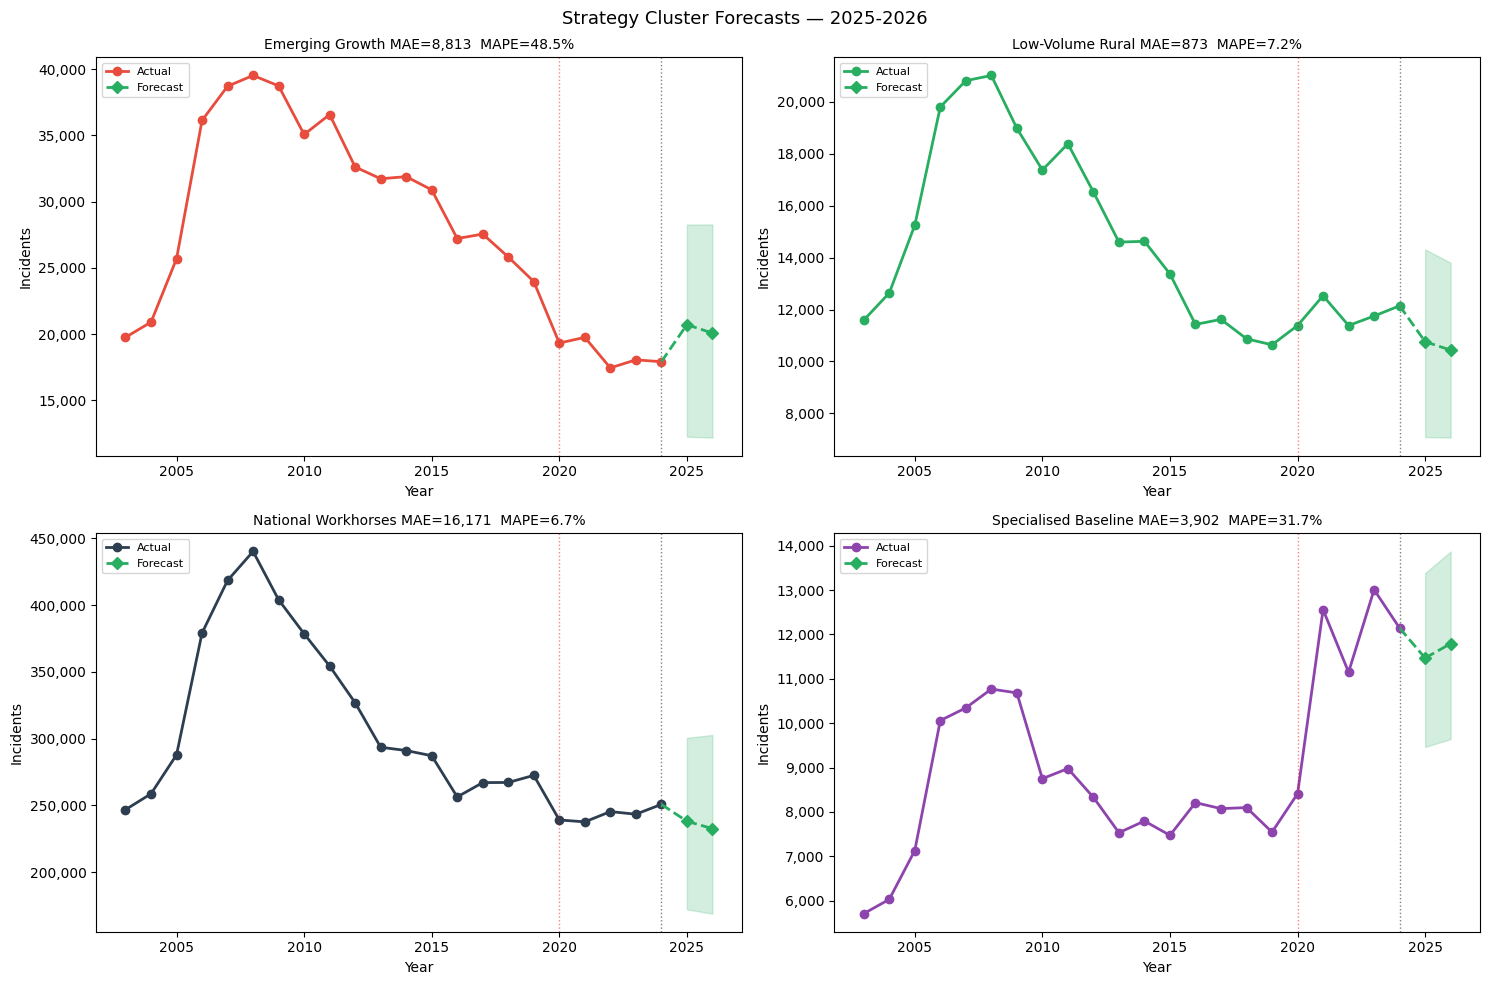

In [41]:
colors = {
    'National Workhorses':  '#2C3E50',
    'Emerging Growth':      '#E74C3C',
    'Low-Volume Rural':     '#27AE60',
    'Specialised Baseline': '#8E44AD'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    ax  = axes[i]
    sub = cluster_ts[cluster_ts['strategy_cluster'] == cluster]
    fc  = cluster_forecasts_df[cluster_forecasts_df['strategy_cluster'] == cluster]
    col = colors.get(cluster, '#2C3E50')

    ax.plot(sub['year'], sub['incidents'],
            marker='o', linewidth=2, label='Actual', color=col)

    # connect last actual to first forecast
    last_val = sub[sub['year'] == 2024]['incidents'].values[0]
    ax.plot([2024, fc['year'].min()],
            [last_val, fc[fc['year'] == fc['year'].min()]['forecast_incidents'].values[0]],
            linewidth=2, linestyle='--', color='#27AE60')

    ax.plot(fc['year'], fc['forecast_incidents'],
            marker='D', linewidth=2, linestyle='--', label='Forecast', color='#27AE60')
    ax.fill_between(fc['year'], fc['lower_ci'], fc['upper_ci'],
                    alpha=0.2, color='#27AE60')

    ax.axvline(x=2020, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(x=2024, color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'{cluster} MAE={cluster_eval[cluster]["mae"]:,.0f}  MAPE={cluster_eval[cluster]["mape"]:,.1f}%', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Incidents')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8)
    ax.grid(False)

plt.suptitle('Strategy Cluster Forecasts — 2025-2026', fontsize=13)
plt.tight_layout()
plt.show()

**Cluster notes:**

Each cluster tells a different story. National Workhorses carry most of the national volume so their trajectory drives the overall national picture. Emerging Growth is the most important cluster to watch — any upward signal here means pressure is building in stations that are not yet at full workload. Low-Volume Rural is stable and has the narrowest confidence intervals. Specialised Baseline is the smallest cluster and the hardest to forecast reliably.

---
## Section 5 — Station Level Forecasts (ARIMA)

ARIMA for each of the top 50 stations individually. The reason I am not using Prophet here is that at station level the individual station pattern matters more than trend modelling — ARIMA fits each station's own series directly.

Where auto_arima fails to find a valid model (can happen with very irregular series), I fall back to Holt-Winters Exponential Smoothing. Any fallback stations are logged.

In [42]:
station_forecasts_list = []
station_diagnostics = []
skipped_stations = []
arima_count = 0
exp_count = 0
naive_count = 0

# get top 50 with cluster and county info
top50_info = risk[risk['rank_risk'] <= 50][['station_code', 'station_name', 'rank_risk']].copy()
top50_info = top50_info.merge(
    master[['station_code', 'strategy_cluster', 'county']].drop_duplicates('station_code'),
    on='station_code',
    how='left'
)

missing_meta = top50_info[top50_info['strategy_cluster'].isna() | top50_info['county'].isna()].copy()
if len(missing_meta) > 0:
    print('warning: some top 50 stations are missing metadata')
    display(missing_meta[['station_code', 'station_name', 'strategy_cluster', 'county']])
else:
    print('top-50 metadata check: all stations have cluster and county values')

for _, row in top50_info.iterrows():
    sc = row['station_code']
    name = row['station_name']
    sub = station_ts[station_ts['station_code'] == sc].sort_values('year').reset_index(drop=True)

    if len(sub) == 0:
        skipped_stations.append({'station_code': sc, 'station_name': name, 'reason': 'no_history_found'})
        continue

    if len(sub) < 5:
        skipped_stations.append({'station_code': sc, 'station_name': name, 'reason': f'not_enough_history_{len(sub)}'})
        continue

    y_full = sub['incidents'].to_numpy(dtype=float)
    train_sub = sub[sub['year'] <= 2020].copy()
    test_sub = sub[sub['year'] >= 2021].copy()

    backtest_mae = np.nan
    baseline_mae = np.nan
    backtest_mape = np.nan
    baseline_mape = np.nan
    beats_naive = np.nan
    eval_model_used = None

    if len(train_sub) >= 5 and len(test_sub) > 0:
        y_train = train_sub['incidents'].to_numpy(dtype=float)

        try:
            eval_model = auto_arima(
                y_train,
                seasonal=False,
                stepwise=True,
                suppress_warnings=True,
                error_action='raise',
                max_p=3, max_q=3, max_d=2
            )
            eval_preds = eval_model.predict(n_periods=len(test_sub))
            eval_model_used = 'ARIMA'
        except Exception:
            try:
                eval_model = ExponentialSmoothing(y_train, trend='add').fit()
                eval_preds = eval_model.forecast(len(test_sub))
                eval_model_used = 'ExponentialSmoothing'
            except Exception:
                eval_preds = np.repeat(y_train[-1], len(test_sub))
                eval_model_used = 'NaiveLastValue'

        eval_preds = np.maximum(0, np.asarray(eval_preds, dtype=float))
        backtest_mae = mean_absolute_error(test_sub['incidents'], eval_preds)
        backtest_mape = mean_absolute_percentage_error(test_sub['incidents'], eval_preds) * 100

        baseline_rows = []
        for yr in test_sub['year']:
            prev = sub[sub['year'] == yr - 1]['incidents']
            if len(prev) > 0:
                baseline_rows.append({
                    'actual': sub[sub['year'] == yr]['incidents'].values[0],
                    'baseline_pred': prev.values[0]
                })
        if baseline_rows:
            baseline_df = pd.DataFrame(baseline_rows)
            baseline_mae = mean_absolute_error(baseline_df['actual'], baseline_df['baseline_pred'])
            baseline_mape = mean_absolute_percentage_error(baseline_df['actual'], baseline_df['baseline_pred']) * 100
            beats_naive = backtest_mae < baseline_mae

    fallback_reason = None

    try:
        final_model = auto_arima(
            y_full,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='raise',
            max_p=3, max_q=3, max_d=2
        )
        fc_vals, ci = final_model.predict(n_periods=2, return_conf_int=True)
        model_used = 'ARIMA'
        model_status = 'full_ok'
        arima_count += 1
    except Exception as arima_error:
        fallback_reason = f'ARIMA failed: {type(arima_error).__name__}: {arima_error}'
        try:
            es_model = ExponentialSmoothing(y_full, trend='add').fit()
            fc_vals = np.asarray(es_model.forecast(2), dtype=float)
            resid = np.asarray(es_model.resid, dtype=float)
            resid = resid[np.isfinite(resid)]
            resid_std = resid.std(ddof=1) if len(resid) > 1 else 0.0
            if not np.isfinite(resid_std) or resid_std == 0:
                diffs = np.diff(y_full)
                diffs = diffs[np.isfinite(diffs)]
                resid_std = diffs.std(ddof=1) if len(diffs) > 1 else max(float(np.std(y_full)), 1.0)
            margins = 1.96 * resid_std * np.sqrt(np.arange(1, 3))
            lower = np.maximum(0, fc_vals - margins)
            upper = np.maximum(lower, fc_vals + margins)
            ci = np.column_stack([lower, upper])
            model_used = 'ExponentialSmoothing'
            model_status = 'full_fallback_es'
            exp_count += 1
        except Exception as es_error:
            fallback_reason = fallback_reason + f' | ExpSmoothing failed: {type(es_error).__name__}: {es_error}'
            fc_vals = np.repeat(y_full[-1], 2)
            diffs = np.diff(y_full)
            diffs = diffs[np.isfinite(diffs)]
            resid_std = diffs.std(ddof=1) if len(diffs) > 1 else max(float(np.std(y_full)), 1.0)
            margins = 1.96 * resid_std * np.sqrt(np.arange(1, 3))
            lower = np.maximum(0, fc_vals - margins)
            upper = np.maximum(lower, fc_vals + margins)
            ci = np.column_stack([lower, upper])
            model_used = 'NaiveLastValue'
            model_status = 'full_fallback_naive'
            naive_count += 1

    fc_vals = np.maximum(0, np.asarray(fc_vals, dtype=float))
    ci = np.maximum(0, np.asarray(ci, dtype=float))

    station_diagnostics.append({
        'station_code': sc,
        'station_name': name,
        'history_points': len(sub),
        'model_used': model_used,
        'eval_model_used': eval_model_used,
        'model_status': model_status,
        'fallback_reason': fallback_reason,
        'backtest_mae': round(backtest_mae, 2) if pd.notna(backtest_mae) else np.nan,
        'baseline_mae': round(baseline_mae, 2) if pd.notna(baseline_mae) else np.nan,
        'backtest_mape': round(backtest_mape, 2) if pd.notna(backtest_mape) else np.nan,
        'baseline_mape': round(baseline_mape, 2) if pd.notna(baseline_mape) else np.nan,
        'beats_naive': beats_naive
    })

    for j, yr in enumerate([2025, 2026]):
        station_forecasts_list.append({
            'station_code': sc,
            'station_name': name,
            'strategy_cluster': row['strategy_cluster'],
            'county': row['county'],
            'rank_risk': row['rank_risk'],
            'year': yr,
            'forecast_incidents': round(fc_vals[j], 0),
            'lower_ci': round(ci[j][0], 0),
            'upper_ci': round(ci[j][1], 0),
            'model_used': model_used,
            'model_status': model_status,
            'fallback_reason': fallback_reason,
            'history_points': len(sub),
            'backtest_mae': round(backtest_mae, 2) if pd.notna(backtest_mae) else np.nan,
            'baseline_mae': round(baseline_mae, 2) if pd.notna(baseline_mae) else np.nan,
            'backtest_mape': round(backtest_mape, 2) if pd.notna(backtest_mape) else np.nan,
            'baseline_mape': round(baseline_mape, 2) if pd.notna(baseline_mape) else np.nan,
            'beats_naive': beats_naive
        })

station_forecasts_df = pd.DataFrame(station_forecasts_list)
station_diagnostics_df = pd.DataFrame(station_diagnostics)
skipped_stations_df = pd.DataFrame(skipped_stations)

print(f'forecasts done for {station_forecasts_df["station_code"].nunique()} stations')
print(f'ARIMA used         : {arima_count} stations')
print(f'Fallback (ExpSmth) : {exp_count} stations')
print(f'Fallback (Naive)   : {naive_count} stations')
print(f'Skipped            : {len(skipped_stations_df)} stations')
if len(station_diagnostics_df) > 0:
    print(f'Beats naive on holdout: {int(station_diagnostics_df["beats_naive"].fillna(False).sum())} stations')
if len(skipped_stations_df) > 0:
    print('skipped stations:')
    display(skipped_stations_df)
print()
print('station model diagnostics (top 10 by risk)')
display(station_diagnostics_df.sort_values('rank_risk' if 'rank_risk' in station_diagnostics_df.columns else 'station_code').head(10))


forecasts done for 50 stations
ARIMA used         : 50 stations
Fallback (ExpSmth) : 0 stations


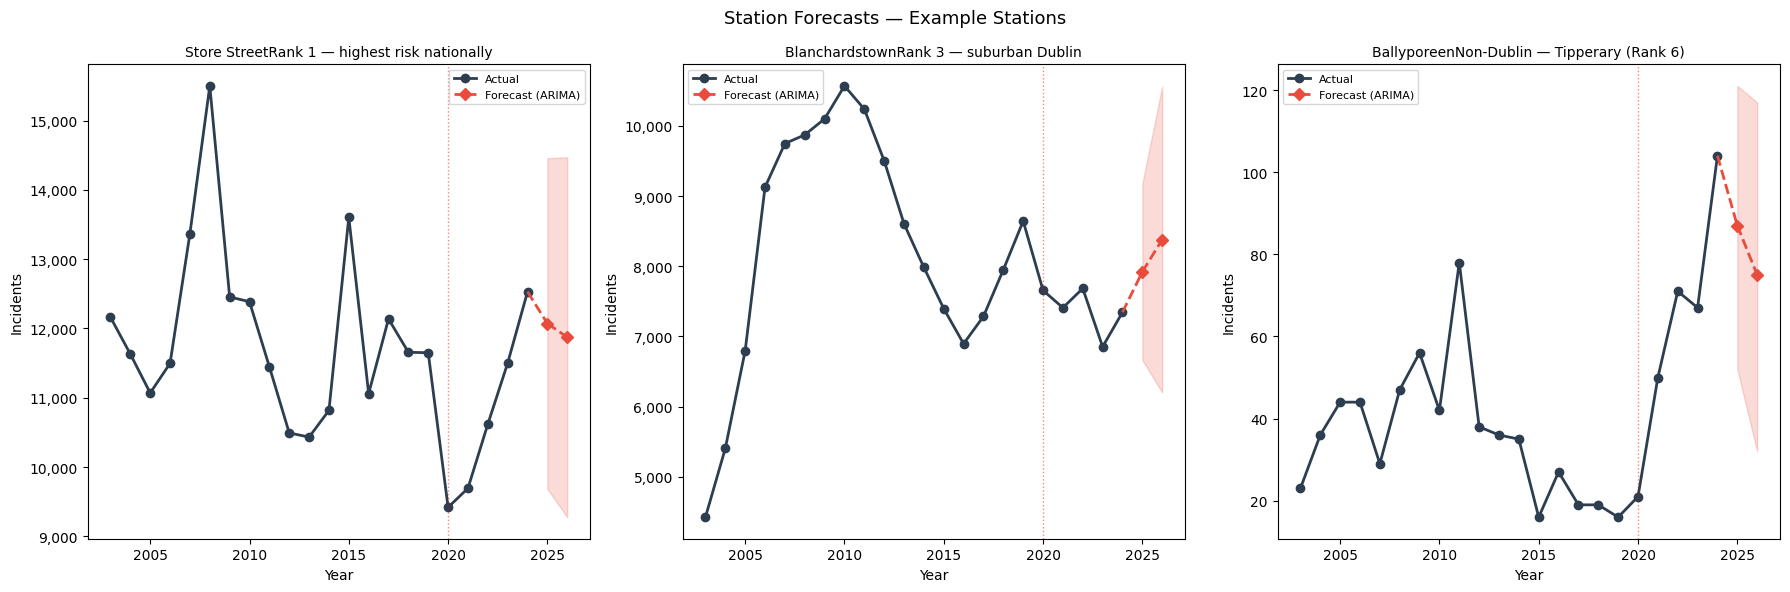

In [43]:
# 3 example plots - Store Street, Blanchardstown, and one non-Dublin station

example_names  = ['Store Street', 'Blanchardstown']
example_labels = [
    'Rank 1 — highest risk nationally',
    'Rank 3 — suburban Dublin'
]

# find the highest ranked non-Dublin station
non_dub = top50_info[~top50_info['county'].str.contains('Dublin', na=False)].sort_values('rank_risk')
if len(non_dub) > 0:
    nd_name  = non_dub.iloc[0]['station_name']
    nd_label = f'Non-Dublin — {non_dub.iloc[0]["county"]} (Rank {non_dub.iloc[0]["rank_risk"]})'
else:
    nd_name  = top50_info.iloc[4]['station_name']
    nd_label = 'Non-Dublin station'

example_names.append(nd_name)
example_labels.append(nd_label)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    ax    = axes[i]
    sname = example_names[i]
    hist  = station_ts[station_ts['station_name'] == sname]
    fc    = station_forecasts_df[station_forecasts_df['station_name'] == sname]

    if len(hist) == 0 or len(fc) == 0:
        ax.set_title(f'{sname} — not found in top 50')
        continue

    model_used = fc['model_used'].iloc[0]

    ax.plot(hist['year'], hist['incidents'],
            marker='o', linewidth=2, label='Actual', color='#2C3E50')

    last_val = hist[hist['year'] == hist['year'].max()]['incidents'].values[0]
    ax.plot([hist['year'].max(), fc['year'].min()],
            [last_val, fc[fc['year'] == fc['year'].min()]['forecast_incidents'].values[0]],
            linewidth=2, linestyle='--', color='#E74C3C')

    ax.plot(fc['year'], fc['forecast_incidents'],
            marker='D', linewidth=2, linestyle='--',
            label=f'Forecast ({model_used})', color='#E74C3C')
    ax.fill_between(fc['year'], fc['lower_ci'], fc['upper_ci'],
                    alpha=0.2, color='#E74C3C')

    ax.axvline(x=2020, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title(f'{sname}{example_labels[i]}', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Incidents')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8)
    ax.grid(False)

plt.suptitle('Station Forecasts — Example Stations', fontsize=13)
plt.tight_layout()
plt.show()

---
### Reconciliation Check

Quick sanity check: does the sum of top 50 station forecasts roughly match the cluster-level forecasts for those same stations?

Note: the station sum will always be less than the cluster forecast because the cluster covers all stations in that cluster, not just the top 50. The question is whether the proportions look sensible.

In [44]:
# compare top 50 station forecasts with full cluster forecasts for 2025

stn_sum_by_cluster = (
    station_forecasts_df[station_forecasts_df['year'] == 2025]
    .groupby('strategy_cluster')['forecast_incidents']
    .sum()
    .reset_index()
    .rename(columns={'forecast_incidents': 'top50_station_sum'})
)

clus_2025 = cluster_forecasts_df[cluster_forecasts_df['year'] == 2025][['strategy_cluster', 'forecast_incidents']].copy()
clus_2025 = clus_2025.rename(columns={'forecast_incidents': 'full_cluster_forecast'})

reconcile = stn_sum_by_cluster.merge(clus_2025, on='strategy_cluster', how='left')
reconcile['top50_pct_of_cluster'] = (
    reconcile['top50_station_sum'] / reconcile['full_cluster_forecast'] * 100
).round(1)

expected_top50 = top50_info['station_code'].nunique()
forecasted_top50 = station_forecasts_df['station_code'].nunique()
missing_top50 = sorted(set(top50_info['station_code']) - set(station_forecasts_df['station_code']))

print('Reconciliation ? top 50 station sum vs full cluster forecast (2025)')
print('top50_pct_of_cluster shows what share the top 50 account for within each cluster')
print(f'forecast coverage: {forecasted_top50}/{expected_top50} top-50 stations produced forecasts')
if missing_top50:
    print('stations without forecasts:', missing_top50)
print()
display(reconcile)


Reconciliation — top 50 station sum vs full cluster forecast (2025)
top50_pct_of_cluster shows what share the top 50 account for within each cluster



,strategy_cluster,top50_station_sum,full_cluster_forecast,top50_pct_of_cluster
0,National Workhorses,142631.0,238219.0,59.9
1,Specialised Baseline,4973.0,11468.0,43.4


---
## Section 6 ? Early Warning Indicators

Two flags per station based on their 2025 forecast:

- **Growth Alert** ? forecast 2025 is more than 15% above the station's recent annual average. Flags stations on an upward trajectory.
- **Pressure Alert** ? forecast 2025 is above the 75th percentile of all stations by recent volume. Flags stations heading into high-volume territory.

`warning_score` just adds the two flags together ? 0 means no alerts, 1 means one alert, 2 means both. Makes it easy to sort in File 7.

These are **heuristic prioritisation flags**, not a validated causal risk score. They are useful for triage, but should be presented to leadership as operational signals rather than proof of future demand.


In [45]:
# start from 2025 station forecasts
fc_2025 = station_forecasts_df[station_forecasts_df['year'] == 2025].copy()

# bring in recent annual average from risk file
recent_vol = risk[['station_code', 'incidents_recent']].copy()
recent_vol['recent_annual_avg'] = recent_vol['incidents_recent'] / 5
fc_2025 = fc_2025.merge(recent_vol, on='station_code', how='left')

# pressure alert threshold across all stations
p75 = (risk['incidents_recent'] / 5).quantile(0.75)
print(f'Pressure alert threshold (75th pct annual avg): {p75:,.0f} incidents')
print('note: these are heuristic flags, not a validated risk score')

fc_2025['growth_alert'] = (fc_2025['forecast_incidents'] > fc_2025['recent_annual_avg'] * 1.15).astype(int)
fc_2025['pressure_alert'] = (fc_2025['forecast_incidents'] > p75).astype(int)
fc_2025['warning_score'] = fc_2025['growth_alert'] + fc_2025['pressure_alert']

fc_2025['scenario_label'] = np.select(
    [
        (fc_2025['growth_alert'] == 1) & (fc_2025['pressure_alert'] == 1),
        (fc_2025['growth_alert'] == 1) & (fc_2025['pressure_alert'] == 0),
        (fc_2025['growth_alert'] == 0) & (fc_2025['pressure_alert'] == 1)
    ],
    ['high_volume_and_growing', 'growth_only', 'pressure_only'],
    default='no_alert'
)

print()
print(f'Growth Alert only  : {((fc_2025["growth_alert"] == 1) & (fc_2025["pressure_alert"] == 0)).sum()} stations')
print(f'Pressure Alert only: {((fc_2025["growth_alert"] == 0) & (fc_2025["pressure_alert"] == 1)).sum()} stations')
print(f'Both alerts (score=2): {(fc_2025["warning_score"] == 2).sum()} stations  <- highest priority')
print(f'Flat/no alert      : {(fc_2025["warning_score"] == 0).sum()} stations')


Pressure alert threshold (75th pct annual avg): 383 incidents

Growth Alert only  : 2 stations
Pressure Alert only: 33 stations
Both alerts (score=2): 5 stations  <- highest priority


In [46]:
# breakdown by cluster
print('Early warning breakdown by cluster:')
ew_summary = (
    fc_2025.groupby('strategy_cluster')
    .agg(
        total_stations=('station_code', 'count'),
        growth_alerts=('growth_alert', 'sum'),
        pressure_alerts=('pressure_alert', 'sum'),
        both_alerts=('warning_score', lambda x: (x == 2).sum())
    )
)
display(ew_summary)

print()
print('Scenario breakdown:')
display(fc_2025['scenario_label'].value_counts().rename_axis('scenario').reset_index(name='stations'))

print()
print('Stations with both alerts ? highest priority watchlist:')
both = fc_2025[fc_2025['warning_score'] == 2].sort_values('forecast_incidents', ascending=False)
display(both[['station_name', 'county', 'strategy_cluster', 'rank_risk',
              'recent_annual_avg', 'forecast_incidents',
              'growth_alert', 'pressure_alert', 'warning_score']].round(0))


Early warning breakdown by cluster:


,total_stations,growth_alerts,pressure_alerts,both_alerts
strategy_cluster,,,,
National Workhorses,35,4,35,4
Specialised Baseline,15,3,3,1



Stations with both alerts — highest priority watchlist:


,station_name,county,strategy_cluster,rank_risk,recent_annual_avg,forecast_incidents,growth_alert,pressure_alert,warning_score
12,Kevin Street,Dublin,National Workhorses,13,3995.0,5125.0,1,1,2
15,Drogheda,Louth,National Workhorses,16,3354.0,4300.0,1,1,2
43,Navan,Meath,National Workhorses,44,2310.0,2963.0,1,1,2
35,Mountjoy,Dublin,National Workhorses,36,2496.0,2873.0,1,1,2
33,Ashford,Wicklow,Specialised Baseline,34,652.0,828.0,1,1,2


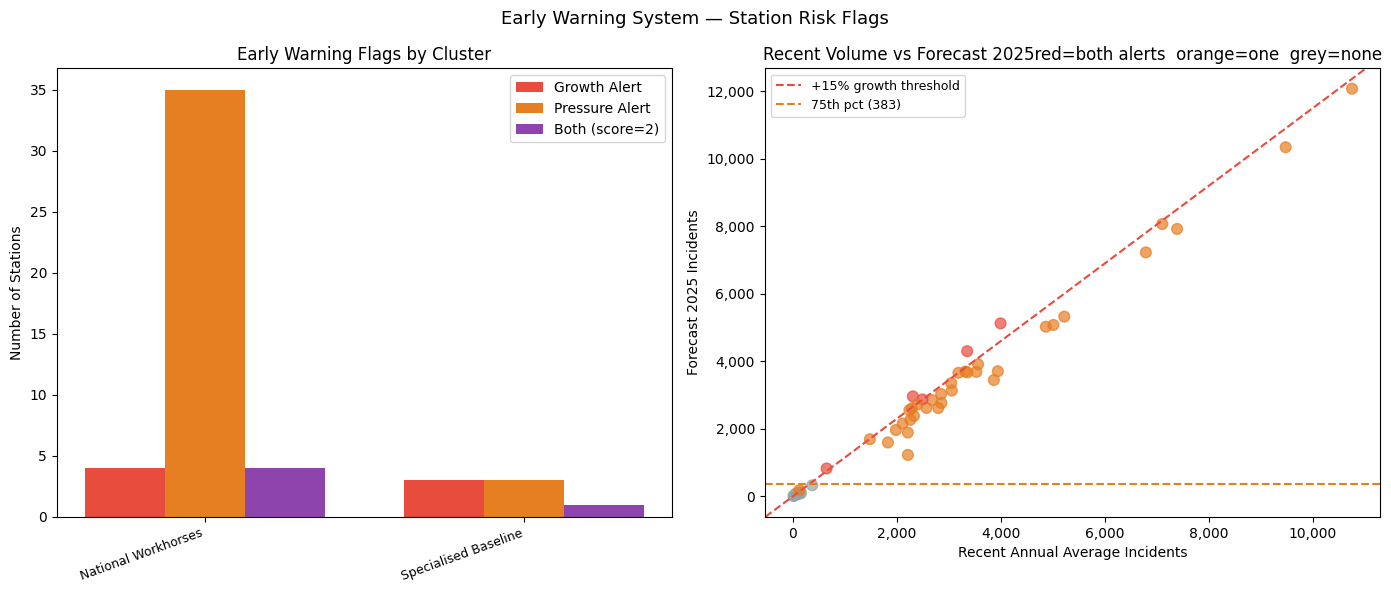

In [47]:
# two charts - bar by cluster and scatter of recent vs forecast

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: bar chart showing how many alerts each cluster has
ew_plot = ew_summary.reset_index()
x = range(len(ew_plot))
w = 0.25
axes[0].bar([i - w for i in x], ew_plot['growth_alerts'],   width=w, label='Growth Alert',    color='#E74C3C')
axes[0].bar([i     for i in x], ew_plot['pressure_alerts'], width=w, label='Pressure Alert',  color='#E67E22')
axes[0].bar([i + w for i in x], ew_plot['both_alerts'],     width=w, label='Both (score=2)',  color='#8E44AD')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(ew_plot['strategy_cluster'], rotation=20, ha='right', fontsize=9)
axes[0].set_title('Early Warning Flags by Cluster')
axes[0].set_ylabel('Number of Stations')
axes[0].legend()
axes[0].grid(False)

# right: scatter - recent volume vs forecast with colour by warning score
dot_colors = fc_2025['warning_score'].map({0: '#95A5A6', 1: '#E67E22', 2: '#E74C3C'})
axes[1].scatter(fc_2025['recent_annual_avg'], fc_2025['forecast_incidents'],
                c=dot_colors, alpha=0.7, s=60)
axes[1].axline((0, 0), slope=1.15, color='#E74C3C', linestyle='--',
               linewidth=1.5, label='+15% growth threshold')
axes[1].axhline(p75, color='#E67E22', linestyle='--',
                linewidth=1.5, label=f'75th pct ({p75:,.0f})')
axes[1].set_title('Recent Volume vs Forecast 2025red=both alerts  orange=one  grey=none')
axes[1].set_xlabel('Recent Annual Average Incidents')
axes[1].set_ylabel('Forecast 2025 Incidents')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(fontsize=9)
axes[1].grid(False)

plt.suptitle('Early Warning System — Station Risk Flags', fontsize=13)
plt.tight_layout()
plt.show()

---
## Save All Outputs

In [48]:
from google.colab import files

# 1. national forecast
nat_save = nat_out[['year', 'forecast_incidents', 'lower_ci', 'upper_ci']].copy().round(0)
nat_save.to_csv('national_forecasts.csv', index=False)
print('saved national_forecasts.csv ?', len(nat_save), 'rows')

# 2. cluster forecasts
cluster_forecasts_df.to_csv('cluster_forecasts.csv', index=False)
print('saved cluster_forecasts.csv ?', len(cluster_forecasts_df), 'rows')

# 3. station forecasts
station_forecasts_df.to_csv('station_forecasts.csv', index=False)
print('saved station_forecasts.csv ?', len(station_forecasts_df), 'rows')

# 4. early warning
ew_out = fc_2025[[
    'station_code', 'station_name', 'county', 'strategy_cluster',
    'rank_risk', 'recent_annual_avg', 'forecast_incidents',
    'lower_ci', 'upper_ci', 'model_used', 'model_status',
    'history_points', 'backtest_mae', 'baseline_mae',
    'backtest_mape', 'baseline_mape', 'beats_naive',
    'growth_alert', 'pressure_alert', 'warning_score', 'scenario_label'
]].copy().round(0)

ew_out.to_csv('early_warning_stations.csv', index=False)
print('saved early_warning_stations.csv ?', len(ew_out), 'rows')

print()
files.download('national_forecasts.csv')
files.download('cluster_forecasts.csv')
files.download('station_forecasts.csv')
files.download('early_warning_stations.csv')


saved national_forecasts.csv — 2 rows
saved cluster_forecasts.csv — 8 rows
saved station_forecasts.csv — 100 rows
saved early_warning_stations.csv — 50 rows



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary

**3 key findings:**
- National incidents are forecast to continue the slow post-COVID recovery through 2025-2026
- Emerging Growth cluster shows the strongest upward signal across clusters, but cluster holdout checks should be read alongside the naive baseline
- The highest-priority watchlist (warning_score = 2) combines stations that are already high-volume and forecast to grow; these are heuristic operational signals, not a validated risk score

**Model review:**
| Level | Model | Assessment |
|---|---|---|
| National | Prophet | Reasonable choice for a short annual series with a 2020 structural break, but only modestly supported because the naive baseline remains competitive |
| Cluster | Prophet | Acceptable when each cluster has a full annual history and distinct trajectory, but should always be compared against the naive baseline |
| Station | ARIMA / ExpSmoothing / Naive fallback | Weakest layer because station series are still short annual histories; keep forecasts, but treat them as decision support rather than strong statistical evidence |

**Outputs:**
| File | What it is |
|---|---|
| `national_forecasts.csv` | 2 rows ? 2025 and 2026 national totals |
| `cluster_forecasts.csv` | 8 rows ? 4 clusters ? 2 years |
| `station_forecasts.csv` | top-50 station forecasts for 2025-2026 plus model diagnostics |
| `early_warning_stations.csv` | one row per forecasted station with alert flags and diagnostic metadata |
